In [8]:
%run Wiskunde_II_Portfolio.ipynb

C:\Users\roeme\AppData\Local\Temp\ipykernel_13820\1424262690.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_transformed = df_transformed.replace(mapdict)


## Tests

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('Mobiliteitsdata.xlsx')
df = df.dropna()
df.head()

,persoon_ID,geslacht,leeftijd,gewicht_KG,burgerlijke_staat,jaarsalaris_eu,huishouden_grootte,stad,provincie,opleiding_niveau,...,elektrisch_auto,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,gebruik_carsharing,co2_uitstoot_per_jaar_KG
0,811069,man,50,52.66,weduwe/weduwnaar,48003.64,5,Almere,Flevoland,MBO,...,nee,13266.05,2040.54,3227.95,480.71,4,1,20,Nooit,7591.93
1,246882,vrouw,65,64.58,samenwonend,55208.63,2,Leeuwarden,Overijssel,WO,...,nee,15229.89,0.00,2298.96,1423.34,5,0,7,Heel soms,8742.25
2,978385,man,49,90.87,samenwonend,29533.78,2,Tilburg,Utrecht,HBO,...,ja,19853.24,1540.46,4504.21,632.48,4,1,2,Altijd,4513.56
3,120468,man,34,80.43,gehuwd,44453.27,2,Maastricht,Utrecht,HBO,...,nee,9935.50,1825.92,4407.56,1266.84,3,2,21,Heel soms,6904.41
4,637034,man,60,72.28,ongehuwd,56497.64,2,Leiden,Gelderland,MBO,...,ja,16266.67,1851.07,1936.12,1676.00,0,5,0,Nooit,4420.80


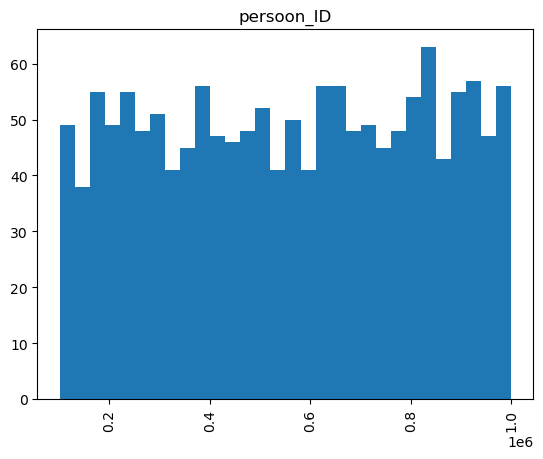

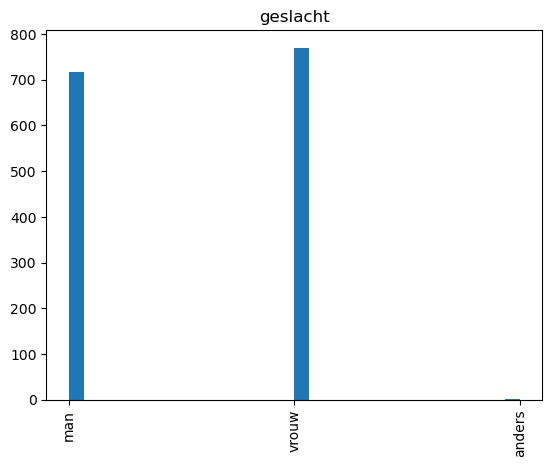

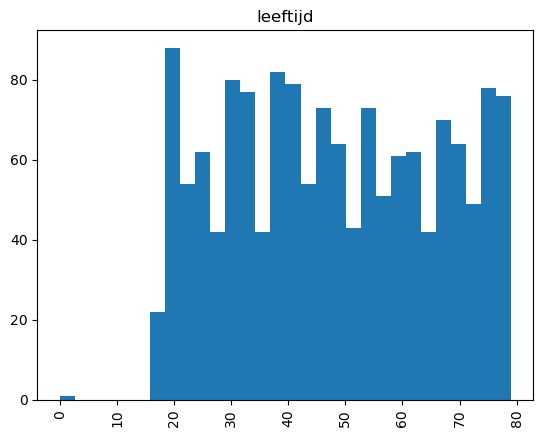

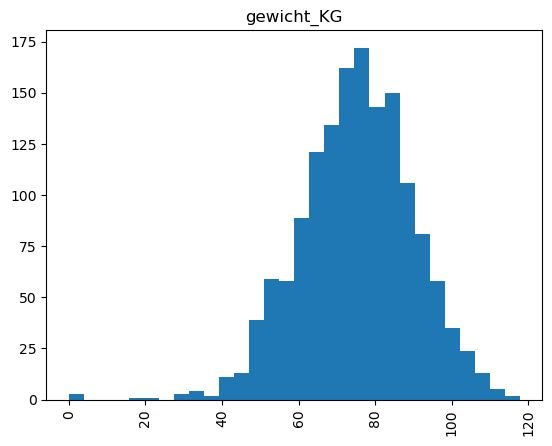

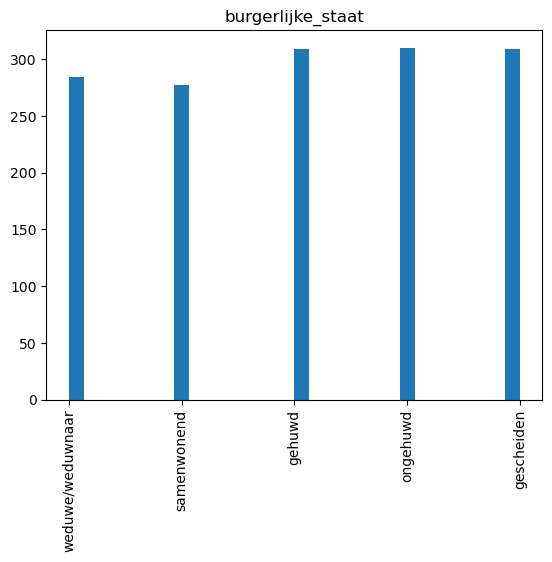

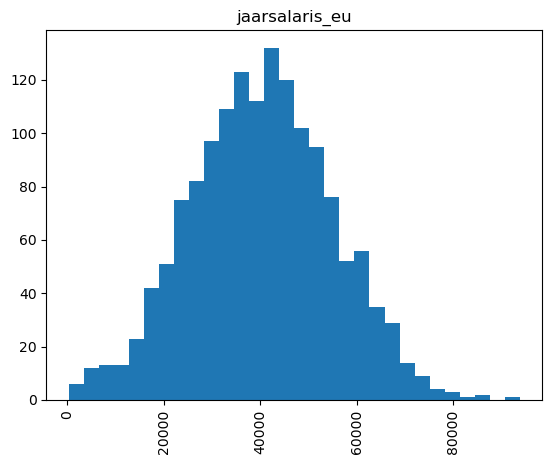

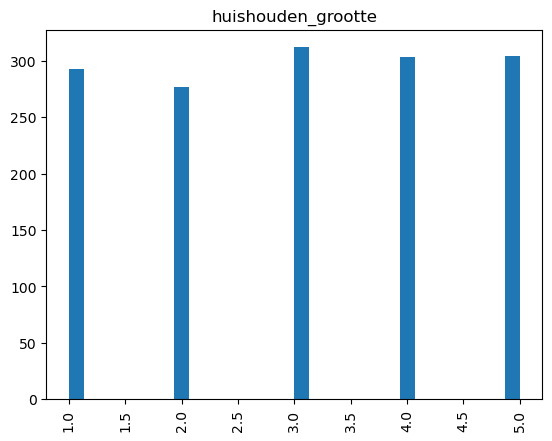

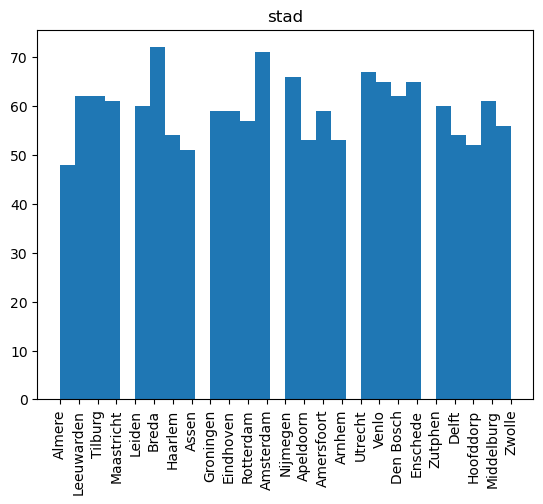

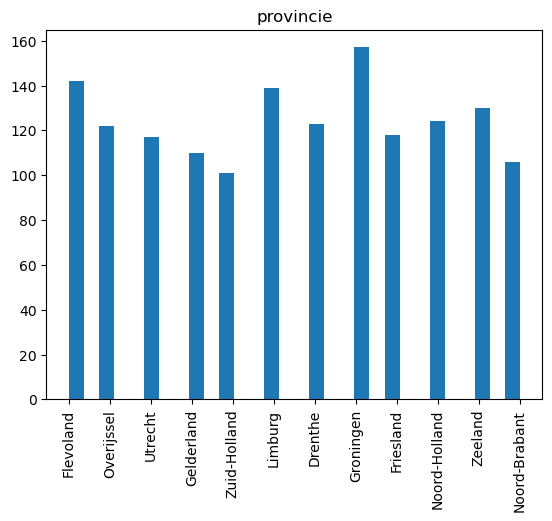

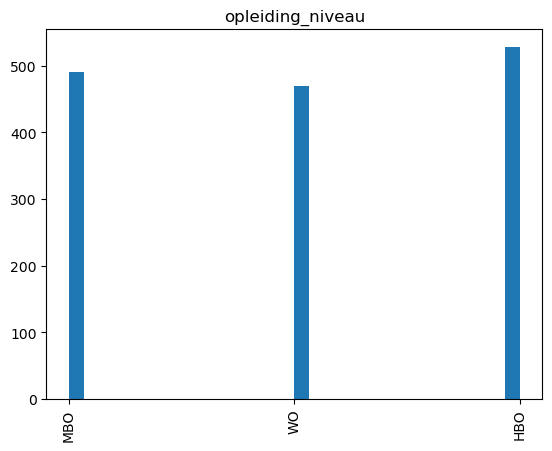

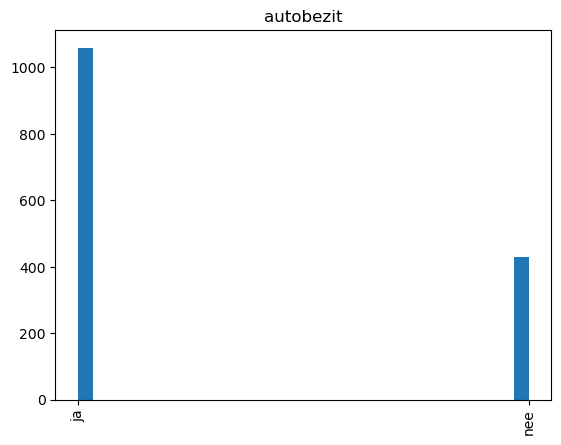

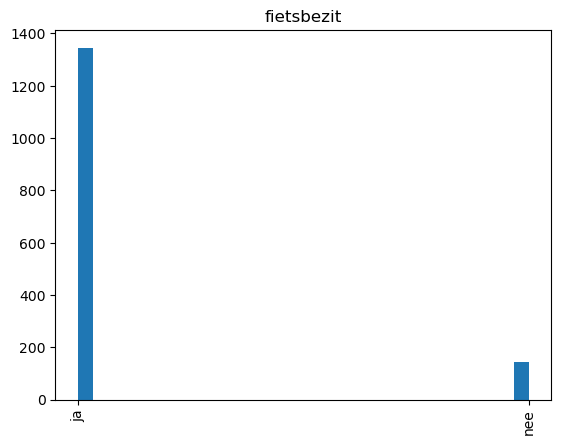

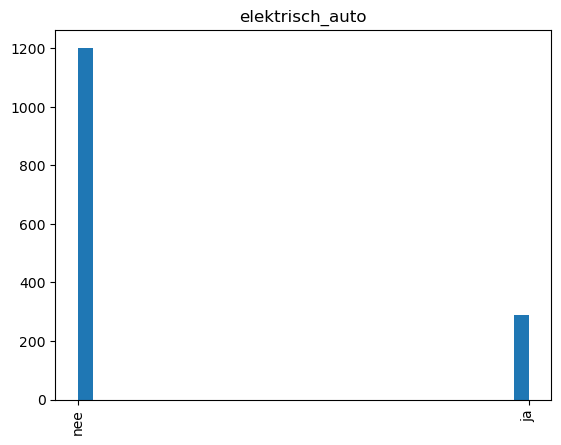

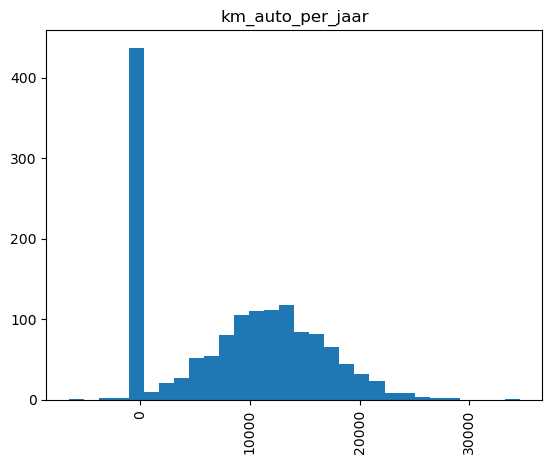

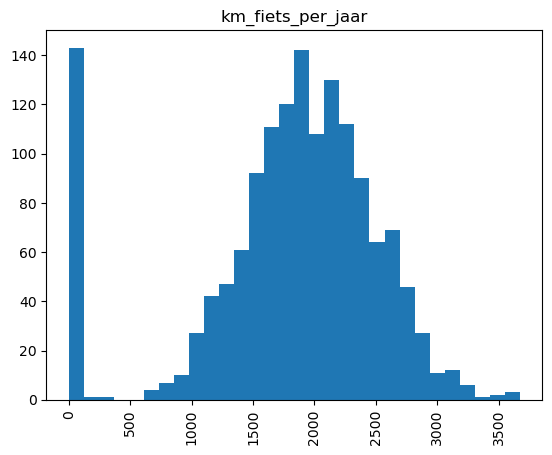

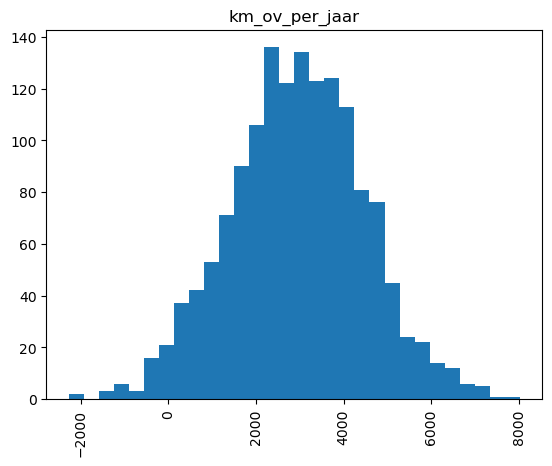

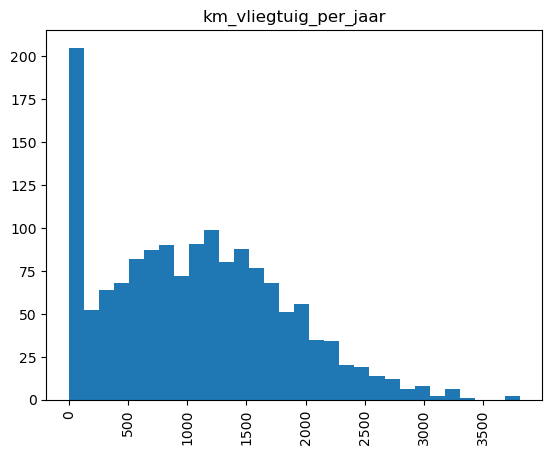

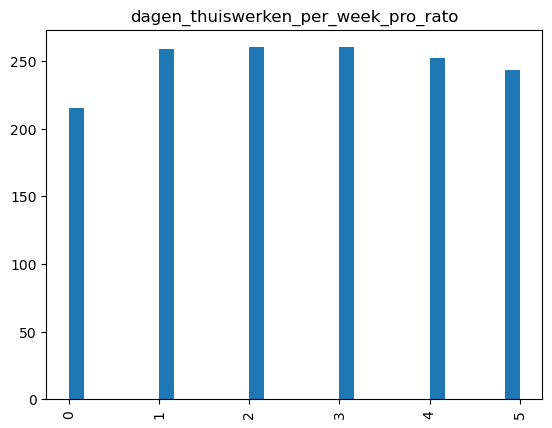

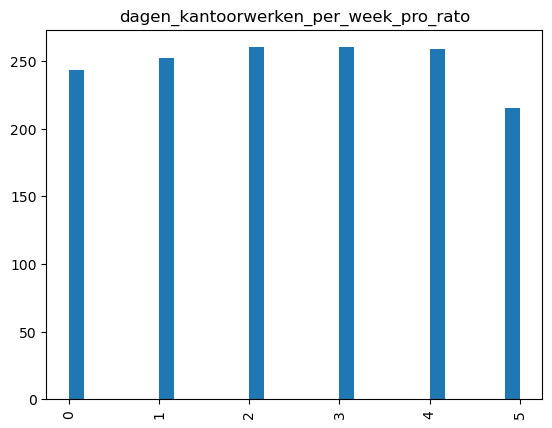

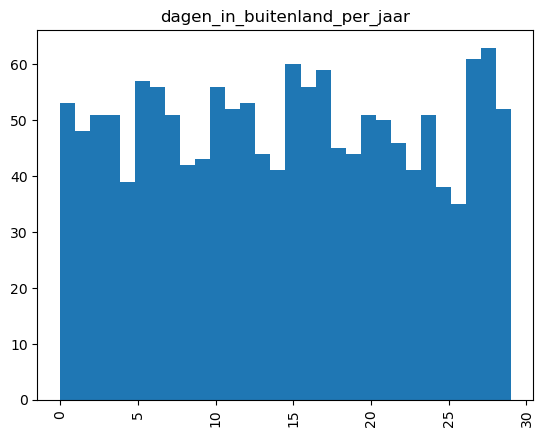

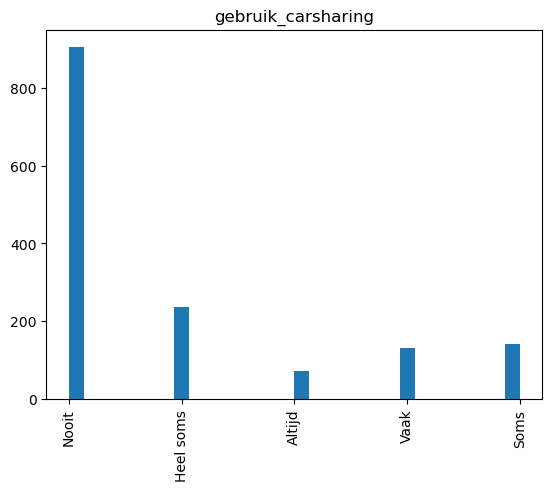

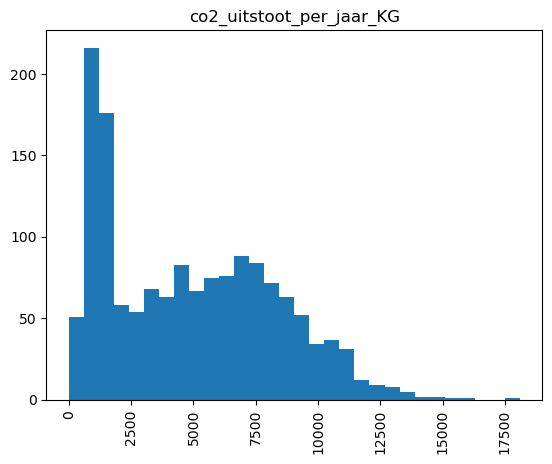

In [10]:
for i in df.columns:
    plt.hist(df[i], bins=30)
    plt.tick_params(axis="x", rotation=90)
    plt.title(i)
    plt.show()

Kolom 1: Index (nvt)
Kolom 2 (geslacht): Modus
Kolom 3 (leeftijd): Mediaan
Kolom 4 (gewicht): Mediaan, uitschieters
Kolom 5 (Relatie status): Modus
Kolom 6 (jaarsalaris): Mediaan
Kolom 7 (huishoudensgrootte): Modus
Kolom 8 (stad): Modus
Kolom 9 (provincie): Modus
Kolom 10 (opleidingsniveau): modus
Kolom 11 (autobezit): Modus
Kolom 12 (fietsbezit): Modus
Kolom 13 (elektrische auto): Modus
Kolom 14 (km auto per jaar): Mediaan
Kolom 15 (km fiets per jaar): Mediaan
Kolom 16 (km ov per jaar): Mediaan
Kolom 17 (km vliegtuig per jaar): Mediaan
Kolom 18 (dagen thuiswerken per week): Modus
Kolom 19 (dagen kantoor per week): Modus
Kolom 20 (dagen in buitenland per jaar): Modus
Kolom 21 (gebruik carsharing): Modus
Kolom 22 (co2 uitstoot per jaar KG): Mediaan


| Kolom | Naam | Methode missende waarden | 
|-------|------|--------------------------|
| 1 | persoon_ID | — |
| 2 | geslacht | Modus |
| 3 | leeftijd | Mediaan |
| 4 | gewicht_KG | Mediaan |
| 5 | burgerlijke_staat | Modus |
| 6 | jaarsalaris_eu | Mediaan |
| 7 | huishouden_grootte | Modus |
| 8 | stad | Modus |
| 9 | provincie | Modus |
| 10 | opleiding_niveau | Modus |
| 11 | autobezit | Modus |
| 12 | fietsbezit | Modus |
| 13 | elektrisch_auto | Modus |
| 14 | km_auto_per_jaar | Mediaan |
| 15 | km_fiets_per_jaar | Mediaan |
| 16 | km_ov_per_jaar | Mediaan |
| 17 | km_vliegtuig_per_jaar | Mediaan |
| 18 | dagen_thuiswerken_per_week_pro_rato | Modus |
| 19 | dagen_kantoorwerken_per_week_pro_rato | Modus |
| 20 | dagen_in_buitenland_per_jaar | Modus |
| 21 | gebruik_carsharing | Modus |
| 22 | co2_uitstoot_per_jaar_KG | Mediaan |

In [11]:
# Missende waarden per kolom met de juiste methode
mediaan_cols = ["leeftijd", "gewicht_KG", "jaarsalaris_eu", "km_auto_per_jaar",
                "km_fiets_per_jaar", "km_ov_per_jaar", "km_vliegtuig_per_jaar",
                "co2_uitstoot_per_jaar_KG"]
modus_cols = ["geslacht", "burgerlijke_staat", "huishouden_grootte", "stad", "provincie",
              "opleiding_niveau", "autobezit", "fietsbezit", "elektrisch_auto",
              "dagen_thuiswerken_per_week_pro_rato", "dagen_kantoorwerken_per_week_pro_rato",
              "dagen_in_buitenland_per_jaar", "gebruik_carsharing"]

for col in mediaan_cols:
    df[col] = df[col].fillna(df[col].median())
for col in modus_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Negatieve waarden vervangen voor mediaan
for col in ["jaarsalaris_eu", "km_auto_per_jaar", "km_ov_per_jaar",
            "km_fiets_per_jaar", "co2_uitstoot_per_jaar_KG"]:
    df.loc[df[col] < 0, col] = df[col].median()

# Onrealistische leeftijd vervangen voor mediaan
df.loc[(df["leeftijd"] < 16) | (df["leeftijd"] > 100), "leeftijd"] = df["leeftijd"].median()

## Mijn taken

### 👤 Roemer — Regressie & Classificatie
**Leerdoelen:** Correlatie/Regressie + (uitloop visualisatie/toets)  
**Vragen 15 t/m 22** + bijhorende Python  
**Start vanaf:** `df_transformed`

| # | Type | Taak |
|---|------|------|
| – | 🐍 Python | Train/test split op `df_transformed` |
| Q15 | ✍️ Schriftelijk | Aantal mogelijke splits (wetensch. notatie) |
| – | 🐍 Python | Lineair regressiemodel trainen → CO₂ voorspellen |
| Q16 | ✍️ Schriftelijk | Welke metric (MAE/RMSE/R²) en waarom |
| Q17 | ✍️ Schriftelijk | Wiskundige formule lineair model + toepassen op groepsgenoot |
| – | 🐍 Python | Top-5 invloedrijkste variabelen bepalen |
| – | 🐍 Python | 2 modellen trainen+testen met 20-fold CV |
| – | 🐍 Python | Metric berekenen op beide modellen |
| – | 🐍 Python | Plot verschil in nauwkeurigheid |
| – | 🐍 Python | Toetsende statistiek op de 20 CV-scores (paired t-test) |
| Q18 | ✍️ Schriftelijk | Welke toets(en) gebruikt en waarom |
| Q19 | ✍️ Schriftelijk | Conclusie statistische toets modellen |
| – | 🐍 Python | Target opsplitsen in 2 klassen (laag/hoog) |
| Q20 | ✍️ Schriftelijk | Welk model voor classificatie en waarom (bv. logistische regressie) |
| – | 🐍 Python | Nieuw classificatiemodel trainen op top-5 features |
| Q21 | ✍️ Schriftelijk | Wiskundige formule classifier + toepassen op groepsgenoot |
| Q22 | ✍️ Schriftelijk | Eindconclusie op basis van de 2 hoofdvragen |

**Verdeling:** 8 schriftelijke vragen + 9 Python-blokken ✅

## Lineair regressie model trainen 

 --- 1. Imports ---
 TODO: importeer pandas, numpy
 TODO: importeer train_test_split   (uit sklearn.model_selection)
 TODO: importeer LinearRegression   (uit sklearn.linear_model)
 TODO: importeer een metric naar keuze (bv. mean_absolute_error, mean_squared_error, r2_score)


 --- 2. Data inladen ---
 Je start vanaf df_transformed (gemaakt door Persoon 2).
 TODO: zorg dat df_transformed beschikbaar is in je notebook
 df_transformed = ...


 --- 3. Features (X) en target (y) scheiden ---
 X = alle onafhankelijke variabelen
 y = de CO2-uitstoot kolom (de afhankelijke variabele)
 TODO: bepaal de naam van de target-kolom in jullie dataset
target_kolom = "..."   # bv. "co2_uitstoot"

 TODO: X = df_transformed zonder de target-kolom
 TODO: y = df_transformed[target_kolom]


 --- 4. Train/test split ---
 Denk na over:
   - test_size (bv. 0.2 = 20% test)
   - random_state (vast getal zodat je reproduceerbaar bent)
 TODO: X_train, X_test, y_train, y_test = train_test_split(...)


 --- 5. Model aanmaken en trainen ---
 Stappen die elk sklearn-model volgt:
   a) model object aanmaken
   b) model.fit(X_train, y_train)   <- hier "leert" het model
 TODO: model = LinearRegression()
 TODO: model.fit(...)


 --- 6. Voorspellen op de testset ---
 TODO: y_pred = model.predict(X_test)


 --- 7. Evalueren ---
 Bereken de metric die je in vraag 16 hebt gekozen.
 TODO: score = ...(y_test, y_pred)
 TODO: print de score


 --- 8. Coëfficiënten bekijken (handig voor vraag 17: formule opstellen) ---
 Een lineair model heeft de vorm:  y = b0 + b1*x1 + b2*x2 + ... + bn*xn
   - model.intercept_   -> b0
   - model.coef_        -> [b1, b2, ..., bn] in volgorde van X.columns
 TODO: print intercept en coëfficiënten netjes met de bijbehorende kolomnamen

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = df_transformed.drop(columns=["co2_uitstoot_per_jaar_KG"])
y = df_transformed["co2_uitstoot_per_jaar_KG"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% gaat naar testset, 80% naar trainingsset
    random_state=42       # Zorgt voor reproduceerbaarheid
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {score:.2f} KG CO2 per jaar")



print(f"De b0 waarde van de formule is: {model.intercept_}")
print(f"De coëfficiënten van de formule zijn: {model.coef_}")



Mean Absolute Error: 595.83 KG CO2 per jaar
De b0 waarde van de formule is: -2469.5453013648957
De coëfficiënten van de formule zijn: [ 1.76165502e-04  5.12507767e-01  1.22929621e+00  1.13500223e-03
  9.76417156e+00  8.12003925e+00  4.41754945e-01  4.76441713e-02
  9.80341633e-02  2.47979508e-01  6.91927479e+01  1.82934092e+01
 -4.41410212e+01  7.71317118e+01 -6.76496661e+01  2.59989476e+03
  4.09688211e+01  7.76932850e+01  2.30856013e+02  1.98339679e+02
  7.50686327e+01  1.62868647e+02  2.32954144e+02  4.04572435e+01
  1.95279861e+02  1.26682572e+02  1.14671477e+02 -2.64502794e+01
 -8.92662444e+00 -1.05930208e+02 -3.67333815e+01  1.88290190e+01]


In [20]:
# Willekeurige rij en voorspelling met formule: y = b0 + b1*x1 + b2*x2 + ...
random_rij = X_test.sample(n=1)
prediction = model.intercept_ + (model.coef_ * random_rij.values[0]).sum()
print(f"Voorspelling: {prediction:.2f} KG CO2 per jaar")

Voorspelling: 8494.69 KG CO2 per jaar
